# ACTUWISE — Module 3 · Notebook 3.3
## Modélisation XGBoost + Clustering — Machine Learning

**Projet :** ACTUWISE — Plateforme d'Analyse Actuarielle, Assurance Non-Vie (Automobile Tunisie)  
**Données :** `dataset_frequence.csv` · `dataset_severite.csv` · `prime_pure_glm.csv`  
**Objectif :** Enrichir le GLM baseline avec le Machine Learning et quantifier le gain de performance

---

### Pipeline du Notebook 3.3

```
dataset_frequence.csv ──► XGBoost Fréquence (classif. binaire)  ──┐
                                                                    ├──► Benchmark GLM vs XGBoost
dataset_severite.csv  ──► XGBoost Sévérité  (régression log)    ──┘      Lorenz · Gini · AUC
                       ──► Clustering K-Means + DBSCAN ──► Ratio combiné par cluster
```

| Modèle | Cible | Méthode | Validation |
|--------|-------|---------|------------|
| XGB Fréquence | `a_eu_sinistre` (0/1) | Classification binaire | Out-of-time 2022–2023 |
| XGB Sévérité  | `log_severite`        | Régression             | Out-of-time 2022–2023 |
| K-Means       | Profils de risque     | Clustering non-supervisé | — |
| DBSCAN        | Détection d'anomalies | Clustering densité       | — |

> *Chen & Guestrin (2016), XGBoost: A Scalable Tree Boosting System, KDD 2016*  
> *Frees, Meyers & Cummings (2014), Predictive Modeling Applications in Actuarial Science*

## 1. Imports et Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, mean_squared_error,
                              r2_score, mean_absolute_error, classification_report)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

C1='#1a3c6e'; C2='#1a7a6a'; C3='#c0392b'; C4='#e67e22'; C5='#8e44ad'
PALETTE = [C1, C2, C3, C4, C5, '#2ecc71', '#3498db', '#e74c3c']
RATIO_FRAIS = 0.25

plt.rcParams.update({
    'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})
print(f'✅ XGBoost version : {xgb.__version__}')
print('✅ Imports OK')

✅ XGBoost version : 3.3.0
✅ Imports OK


## 2. Chargement et Préparation des Données

### 2.1 Chargement


In [2]:
df_freq = pd.read_csv('dataset_module3_frequence.csv')
df_sev  = pd.read_csv('dataset_module3_severite.csv')

# Charger prime pure GLM si disponible (benchmark)
try:
    df_pp_glm = pd.read_csv('prime_pure_glm.csv', index_col=0)
    print(f'✅ prime_pure_glm.csv chargé ({len(df_pp_glm):,} lignes)')
except FileNotFoundError:
    df_pp_glm = None
    print('⚠️  prime_pure_glm.csv absent — benchmark GLM vs XGBoost sur Lorenz désactivé')

print(f'\ndataset_frequence : {len(df_freq):,} lignes | {df_freq.shape[1]} colonnes')
print(f'dataset_severite  : {len(df_sev):,}  lignes | {df_sev.shape[1]} colonnes')

✅ prime_pure_glm.csv chargé (94,846 lignes)

dataset_frequence : 94,846 lignes | 31 colonnes
dataset_severite  : 39,873  lignes | 31 colonnes


In [3]:
# ── Détection automatique des colonnes ───────────────────────────────
col_bin     = next((c for c in df_freq.columns if 'sinistre' in c.lower() and df_freq[c].nunique()==2), None)
col_nb      = next((c for c in df_freq.columns if 'nb_sinistre' in c.lower()), None)
col_freq    = next((c for c in df_freq.columns if 'frequence' in c.lower()), None)
col_expo    = next((c for c in df_freq.columns if 'exposition' in c.lower() or 'expo' in c.lower()), None)
col_sev     = next((c for c in df_sev.columns  if 'severite' in c.lower() and 'log' not in c.lower()), None)
col_log_sev = next((c for c in df_sev.columns  if 'log' in c.lower() and 'sev' in c.lower()), None)
col_primes  = next((c for c in df_freq.columns if 'prime' in c.lower()), None)
col_lr      = next((c for c in df_freq.columns if 'loss_ratio' in c.lower()), None)
col_annee   = next((c for c in df_freq.columns if 'annee' in c.lower() or 'year' == c.lower() or 'an_' in c.lower()), None)

col_usage   = next((c for c in df_freq.columns if 'usage' in c.lower()), None)
col_energie = next((c for c in df_freq.columns if 'energ' in c.lower() or 'carburant' in c.lower()), None)
col_region  = next((c for c in df_freq.columns if 'region' in c.lower() or 'zone' in c.lower() or 'wilaya' in c.lower()), None)
col_bm      = next((c for c in df_freq.columns if 'bonus' in c.lower() or 'malus' in c.lower() or 'bm'==c.lower()), None)
col_age     = next((c for c in df_freq.columns if 'age' in c.lower() and 'veh' not in c.lower()), None)
col_age_veh = next((c for c in df_freq.columns if 'ancien' in c.lower() or ('age' in c.lower() and 'veh' in c.lower())), None)

# log_severite — créer si absent
if col_sev and not col_log_sev:
    df_sev['log_severite'] = np.log(df_sev[col_sev].clip(lower=1))
    col_log_sev = 'log_severite'

print('Colonnes identifiées :')
for name, val in [('Cible binaire (fréq)', col_bin), ('Nb sinistres', col_nb),
                   ('Exposition', col_expo), ('Sévérité', col_sev),
                   ('log_sévérité', col_log_sev), ('Primes', col_primes),
                   ('Année', col_annee), ('Bonus-Malus', col_bm)]:
    print(f'  {name:<25}: {val}')

Colonnes identifiées :
  Cible binaire (fréq)     : a_eu_sinistre
  Nb sinistres             : nb_sinistres_total
  Exposition               : exposition
  Sévérité                 : severite_sinistres
  log_sévérité             : log_severite
  Primes                   : log_prime_annuelle
  Année                    : None
  Bonus-Malus              : None


### 2.2 Feature Engineering et Encodage

XGBoost accepte nativement les variables numériques.  
Les catégorielles sont encodées en **LabelEncoding** (suffisant pour les arbres).  
L'encodage OHE n'est pas nécessaire pour XGBoost — les splits sur valeurs entières  
sont gérés nativement par l'algorithme.

In [4]:
# ── Sélection des features ────────────────────────────────────────────
cat_cols  = [c for c in [col_usage, col_energie, col_region, col_bm] if c]
num_cols  = [c for c in [col_age, col_age_veh, col_expo] if c]
all_feats = cat_cols + num_cols

# Ajouter features numériques supplémentaires si disponibles
extra_num = [c for c in df_freq.select_dtypes(include=[np.number]).columns
             if c not in all_feats + [col_bin, col_nb, col_freq, col_primes,
                                       col_expo, col_lr, col_annee]
             and not any(kw in c.lower() for kw in ['id', 'code', 'index', 'sinistre'])]
all_feats += extra_num[:5]

print(f'Features catégorielles : {cat_cols}')
print(f'Features numériques    : {num_cols + extra_num[:5]}')
print(f'Total features         : {len(all_feats)}')

Features catégorielles : ['Usage_Promenade et affaire', 'Energie_Essence', 'region_freq']
Features numériques    : ['age_conducteur', 'anciennete_vehicule', 'exposition', 'age_manquant', 'sexe_masculin', 'Puissance fiscale', 'Valeur venale', 'Classe BM']
Total features         : 11


In [5]:
# ── Encodage LabelEncoding des catégorielles ─────────────────────────
df_model = df_freq.copy()
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c].astype(str).fillna('INCONNU'))
    le_dict[c] = le

# Cible binaire
if col_bin:
    df_model['target_freq'] = df_model[col_bin].astype(int)
elif col_nb:
    df_model['target_freq'] = (df_model[col_nb] > 0).astype(int)
else:
    df_model['target_freq'] = 0
    print('⚠️ Cible binaire non trouvée — vérifier les colonnes')

# Sévérité
df_sev_model = df_sev.copy()
for c in cat_cols:
    if c in df_sev_model.columns and c in le_dict:
        df_sev_model[c] = df_sev_model[c].astype(str).fillna('INCONNU')
        known = set(le_dict[c].classes_)
        df_sev_model[c] = df_sev_model[c].apply(lambda x: x if x in known else 'INCONNU')
        df_sev_model[c] = le_dict[c].transform(df_sev_model[c])

print(f'✅ Encodage terminé')
print(f'   Taux sinistralité (target_freq) : {df_model["target_freq"].mean()*100:.1f}%')

✅ Encodage terminé
   Taux sinistralité (target_freq) : 49.0%


## 3. Validation Temporelle Out-of-Time

**Principe :** En actuariat, la validation temporelle est plus rigoureuse que la validation aléatoire.  
Elle simule la vraie performance prédictive : le modèle est entraîné sur le passé et testé sur le futur.  

| Split | Années | Usage |
|-------|--------|-------|
| **Train** | 2018–2021 | Entraînement + tuning |
| **Test** | 2022–2023 | Évaluation out-of-time |

> *Si la colonne année est absente, on utilise un split 80/20 aléatoire stratifié.*

In [6]:
feats_available = [f for f in all_feats if f in df_model.columns]

X = df_model[feats_available].fillna(df_model[feats_available].median(numeric_only=True))
y_freq = df_model['target_freq']

if col_annee and col_annee in df_model.columns:
    annees = df_model[col_annee]
    train_mask = annees <= 2021
    test_mask  = annees >= 2022
    X_train_f, X_test_f = X[train_mask], X[test_mask]
    y_train_f, y_test_f = y_freq[train_mask], y_freq[test_mask]
    print(f'Split temporel out-of-time :')
    print(f'  Train (2018–2021) : {len(X_train_f):,} obs. | {y_train_f.mean()*100:.1f}% sinistres')
    print(f'  Test  (2022–2023) : {len(X_test_f):,}  obs. | {y_test_f.mean()*100:.1f}% sinistres')
else:
    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        X, y_freq, test_size=0.2, random_state=42, stratify=y_freq)
    print(f'Split aléatoire stratifié 80/20 :')
    print(f'  Train : {len(X_train_f):,} | Test : {len(X_test_f):,}')

# Sévérité
feats_sev_avail = [f for f in feats_available if f in df_sev_model.columns]
df_sev_clean = df_sev_model[df_sev_model[col_sev] > 0].copy() if col_sev else df_sev_model.copy()
X_sev = df_sev_clean[feats_sev_avail].fillna(df_sev_clean[feats_sev_avail].median(numeric_only=True))
y_sev = df_sev_clean[col_log_sev].fillna(0) if col_log_sev else None

if col_annee and col_annee in df_sev_clean.columns and y_sev is not None:
    ann_s = df_sev_clean[col_annee]
    X_train_s, X_test_s = X_sev[ann_s <= 2021], X_sev[ann_s >= 2022]
    y_train_s, y_test_s = y_sev[ann_s <= 2021], y_sev[ann_s >= 2022]
    print(f'  Sévérité train : {len(X_train_s):,} | test : {len(X_test_s):,}')
elif y_sev is not None:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_sev, y_sev, test_size=0.2, random_state=42)
else:
    X_train_s = X_test_s = y_train_s = y_test_s = None

Split aléatoire stratifié 80/20 :
  Train : 75,876 | Test : 18,970


## 4. XGBoost Fréquence — Classification Binaire

### 4.1 Hyperparameter Tuning

On effectue un **GridSearchCV** sur une grille réduite pour trouver les meilleurs hyperparamètres.  
La métrique d'optimisation est l'**AUC-ROC** (standard pour la détection de sinistres binaire).

In [7]:
# ── Grille hyperparamètres XGBoost Fréquence ─────────────────────────
param_grid_freq = {
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'n_estimators'    : [100, 200],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_freq_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

cv_freq = GridSearchCV(
    xgb_freq_base, param_grid_freq,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

print('🔄 GridSearchCV XGBoost Fréquence en cours...')
cv_freq.fit(X_train_f, y_train_f)
print(f'\n✅ Meilleurs hyperparamètres fréquence :')
for k, v in cv_freq.best_params_.items():
    print(f'   {k:<25}: {v}')
print(f'   AUC CV (mean)         : {cv_freq.best_score_:.4f}')

🔄 GridSearchCV XGBoost Fréquence en cours...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

✅ Meilleurs hyperparamètres fréquence :
   colsample_bytree         : 1.0
   learning_rate            : 0.2
   max_depth                : 7
   n_estimators             : 200
   subsample                : 1.0
   AUC CV (mean)         : 0.8220


In [8]:
# ── Modèle final XGBoost Fréquence ───────────────────────────────────
xgb_freq = xgb.XGBClassifier(
    **cv_freq.best_params_,
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_freq.fit(
    X_train_f, y_train_f,
    eval_set=[(X_test_f, y_test_f)],
    verbose=False
)

# Métriques
y_prob_f = xgb_freq.predict_proba(X_test_f)[:, 1]
y_pred_f = (y_prob_f >= 0.5).astype(int)
auc_xgb_f = roc_auc_score(y_test_f, y_prob_f)

print('=== Métriques XGBoost Fréquence (Test out-of-time) ===')
print(f'  AUC-ROC  : {auc_xgb_f:.4f}')
print()
print(classification_report(y_test_f, y_pred_f, target_names=['Sans sinistre', 'Avec sinistre']))

=== Métriques XGBoost Fréquence (Test out-of-time) ===
  AUC-ROC  : 0.8460

               precision    recall  f1-score   support

Sans sinistre       0.78      0.76      0.77      9667
Avec sinistre       0.76      0.77      0.76      9303

     accuracy                           0.77     18970
    macro avg       0.77      0.77      0.77     18970
 weighted avg       0.77      0.77      0.77     18970



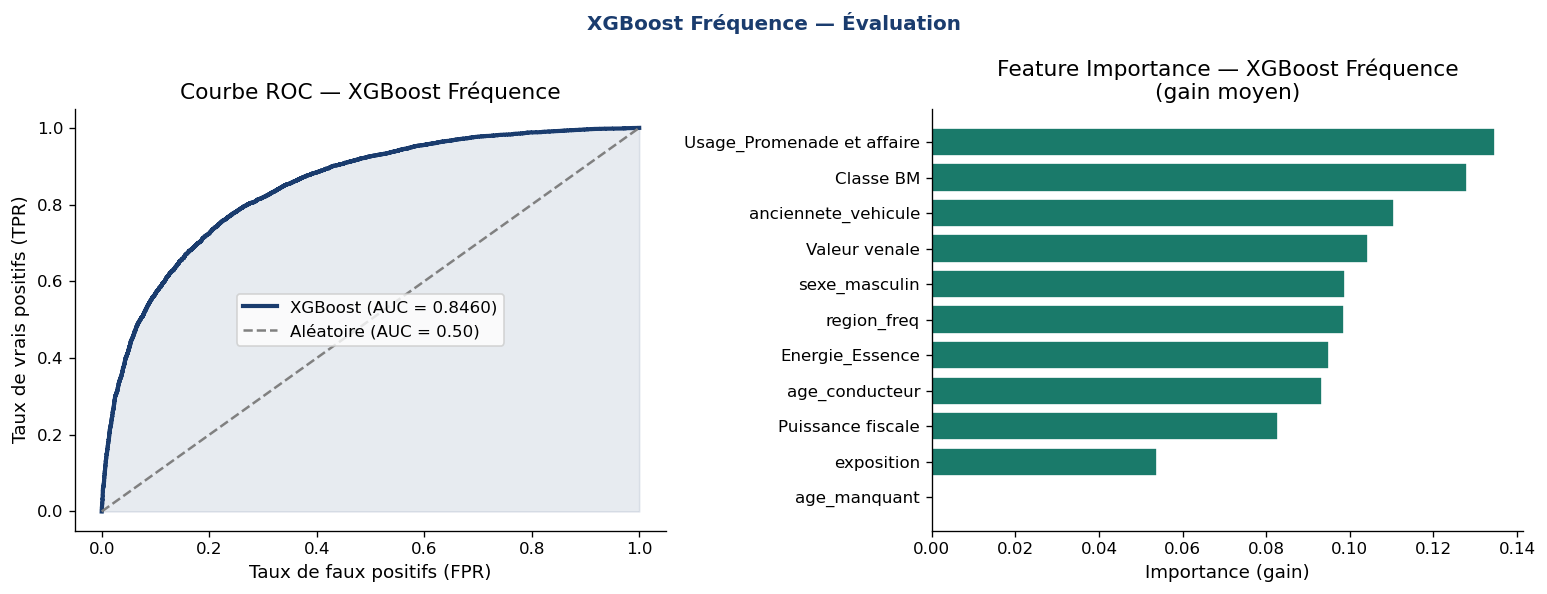

✅ fig_33_xgb_freq_roc.png


In [9]:
# ── Courbe ROC ────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_f, y_prob_f)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XGBoost Fréquence — Évaluation', fontweight='bold', color=C1)

# Courbe ROC
ax = axes[0]
ax.plot(fpr, tpr, color=C1, lw=2.5, label=f'XGBoost (AUC = {auc_xgb_f:.4f})')
ax.plot([0,1],[0,1], color='grey', lw=1.5, ls='--', label='Aléatoire (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color=C1)
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR)')
ax.set_title('Courbe ROC — XGBoost Fréquence')
ax.legend(fontsize=10)

# Feature importance
ax = axes[1]
imp = pd.Series(xgb_freq.feature_importances_, index=feats_available).sort_values(ascending=True).tail(15)
ax.barh(imp.index, imp.values, color=C2, edgecolor='white')
ax.set_title('Feature Importance — XGBoost Fréquence\n(gain moyen)')
ax.set_xlabel('Importance (gain)')

plt.tight_layout()
plt.savefig('fig_33_xgb_freq_roc.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ fig_33_xgb_freq_roc.png')

## 5. XGBoost Sévérité — Régression sur log(Sévérité)

On modélise `log_severite` (transformation log pour stabiliser la variance et symétriser la distribution).  
La prédiction est ensuite retransformée : $\hat{\mu}_i = \exp(\hat{y}_i)$  

> *La régression sur log est équivalente à un GLM log-normal — elle est souvent meilleure que
le GLM Gamma sur des données avec queues très lourdes.*

In [10]:
if X_train_s is not None and y_train_s is not None:
    param_grid_sev = {
        'max_depth'       : [3, 5, 7],
        'learning_rate'   : [0.05, 0.1],
        'n_estimators'    : [100, 200],
        'subsample'       : [0.8, 1.0],
    }

    xgb_sev_base = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42, n_jobs=-1
    )

    cv_sev = GridSearchCV(
        xgb_sev_base, param_grid_sev,
        scoring='neg_root_mean_squared_error',
        cv=3, n_jobs=-1, verbose=1
    )

    print('🔄 GridSearchCV XGBoost Sévérité en cours...')
    cv_sev.fit(X_train_s, y_train_s)
    print(f'\n✅ Meilleurs hyperparamètres sévérité :')
    for k, v in cv_sev.best_params_.items():
        print(f'   {k:<25}: {v}')
else:
    print('⚠️ Données sévérité indisponibles')

🔄 GridSearchCV XGBoost Sévérité en cours...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Meilleurs hyperparamètres sévérité :
   learning_rate            : 0.1
   max_depth                : 7
   n_estimators             : 200
   subsample                : 0.8


In [11]:
if X_train_s is not None:
    xgb_sev = xgb.XGBRegressor(
        **cv_sev.best_params_,
        objective='reg:squarederror',
        random_state=42, n_jobs=-1
    )
    xgb_sev.fit(X_train_s, y_train_s,
                eval_set=[(X_test_s, y_test_s)], verbose=False)

    y_pred_log_s = xgb_sev.predict(X_test_s)
    y_pred_s     = np.exp(y_pred_log_s)  # retransformation
    y_true_s     = np.exp(y_test_s)       # retransformation

    rmse_xgb_s = np.sqrt(mean_squared_error(y_true_s, y_pred_s))
    mae_xgb_s  = mean_absolute_error(y_true_s, y_pred_s)
    r2_xgb_s   = r2_score(y_true_s, y_pred_s)
    rmse_log_s = np.sqrt(mean_squared_error(y_test_s, y_pred_log_s))

    print('=== Métriques XGBoost Sévérité (Test out-of-time) ===')
    print(f'  RMSE (DT, espace original) : {rmse_xgb_s:,.2f}')
    print(f'  MAE  (DT, espace original) : {mae_xgb_s:,.2f}')
    print(f'  R²   (espace original)     : {r2_xgb_s:.4f}')
    print(f'  RMSE (espace log)          : {rmse_log_s:.4f}')
else:
    xgb_sev = None
    rmse_xgb_s = mae_xgb_s = r2_xgb_s = None

=== Métriques XGBoost Sévérité (Test out-of-time) ===
  RMSE (DT, espace original) : 3,504.93
  MAE  (DT, espace original) : 846.95
  R²   (espace original)     : 0.0545
  RMSE (espace log)          : 1.1861


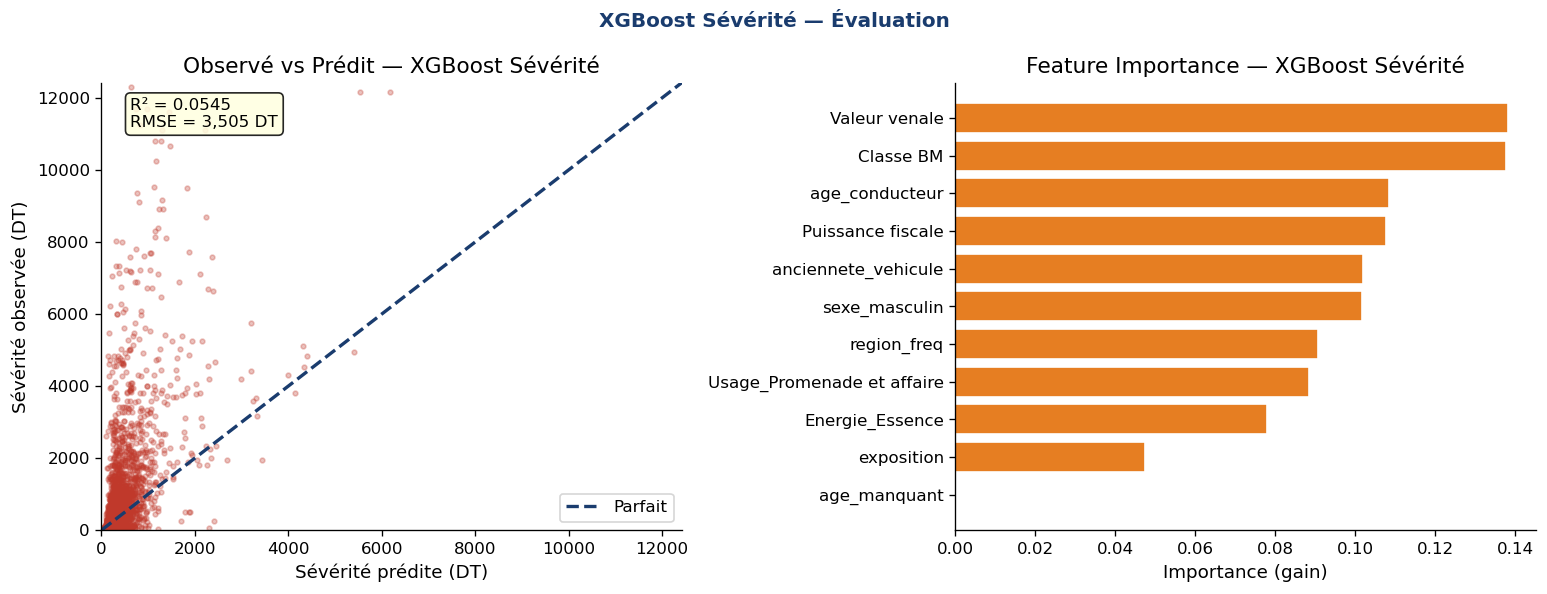

✅ fig_33_xgb_sev_diagnostic.png


In [12]:
if xgb_sev is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('XGBoost Sévérité — Évaluation', fontweight='bold', color=C1)

    ax = axes[0]
    sample_idx = np.random.choice(len(y_true_s), min(3000, len(y_true_s)), replace=False)
    ax.scatter(y_pred_s[sample_idx], y_true_s.values[sample_idx] if hasattr(y_true_s,'values') else y_true_s[sample_idx],
               alpha=0.3, s=8, color=C3)
    lim = np.percentile(y_true_s, 99)
    ax.plot([0, lim], [0, lim], color=C1, lw=2, ls='--', label='Parfait')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Sévérité prédite (DT)')
    ax.set_ylabel('Sévérité observée (DT)')
    ax.set_title('Observé vs Prédit — XGBoost Sévérité')
    ax.text(0.05, 0.90, f'R² = {r2_xgb_s:.4f}\nRMSE = {rmse_xgb_s:,.0f} DT',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
    ax.legend()

    ax = axes[1]
    imp_s = pd.Series(xgb_sev.feature_importances_, index=feats_sev_avail).sort_values(ascending=True).tail(15)
    ax.barh(imp_s.index, imp_s.values, color=C4, edgecolor='white')
    ax.set_title('Feature Importance — XGBoost Sévérité')
    ax.set_xlabel('Importance (gain)')

    plt.tight_layout()
    plt.savefig('fig_33_xgb_sev_diagnostic.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ fig_33_xgb_sev_diagnostic.png')

## 6. Courbe de Lorenz Actuarielle — Benchmark GLM vs XGBoost

On compare les courbes de Lorenz des deux modèles sur le même graphique.  
Le score utilisé pour XGBoost est la **probabilité de sinistre prédite** (`predict_proba`).  
Plus la courbe est éloignée de la diagonale, meilleur est le modèle.

In [13]:
def lorenz_gini(y_true, y_score, weights=None):
    df_l = pd.DataFrame({'y': np.asarray(y_true), 'score': np.asarray(y_score)})
    df_l['w'] = np.asarray(weights) if weights is not None else 1.0
    df_l = df_l.replace([np.inf, -np.inf], np.nan).dropna().sort_values('score')
    cum_w = np.cumsum(df_l['w']) / df_l['w'].sum()
    cum_s = np.cumsum(df_l['y'] * df_l['w']) / (df_l['y'] * df_l['w']).sum()
    gini  = 2 * np.trapz(cum_s, cum_w) - 1
    return cum_w.values, cum_s.values, gini

# XGBoost Lorenz
cum_w_xgb, cum_s_xgb, gini_xgb = lorenz_gini(
    y_test_f.values, y_prob_f,
    weights=X_test_f[col_expo].values if col_expo in X_test_f.columns else None
)
print(f'Gini XGBoost : {gini_xgb:.4f}')

# Charger Gini GLM depuis fichier si disponible
try:
    df_bench_glm = pd.read_csv('benchmark_module_32_glm.csv', index_col=0)
    gini_glm = float(df_bench_glm.loc['GLM Baseline', 'Gini actuariel'])
    print(f'Gini GLM     : {gini_glm:.4f}')
except:
    gini_glm = None
    print('⚠️ Gini GLM non disponible (benchmark_module_32_glm.csv absent)')

Gini XGBoost : -0.3294
Gini GLM     : -0.0659


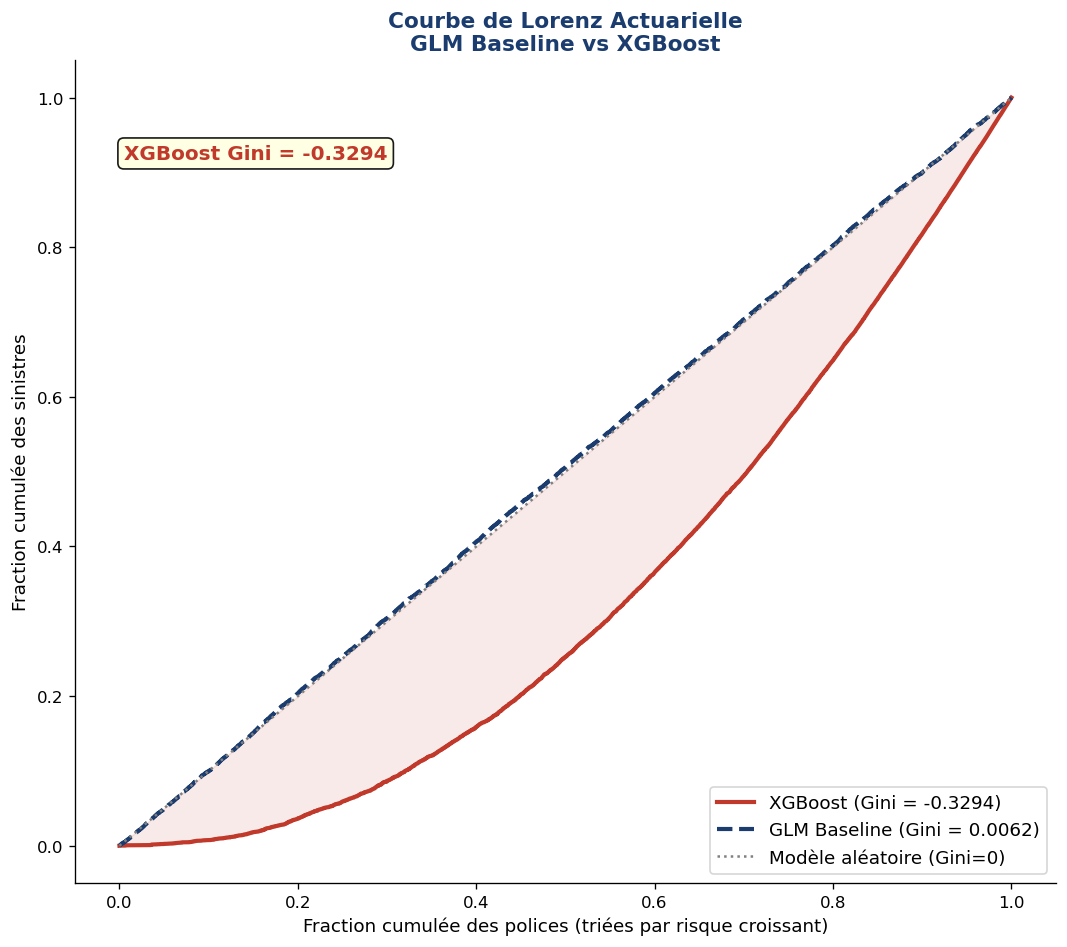

✅ fig_33_lorenz_benchmark.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(cum_w_xgb, cum_s_xgb, color=C3, lw=2.5, label=f'XGBoost (Gini = {gini_xgb:.4f})')

# GLM depuis prime_pure_glm si disponible
if df_pp_glm is not None and col_nb in df_model.columns:
    try:
        pp_glm_vals = df_pp_glm['prime_pure'].values[:len(y_test_f)]
        y_obs_test  = y_test_f.values
        w_test = X_test_f[col_expo].values if col_expo in X_test_f.columns else None
        cum_w_glm, cum_s_glm, gini_glm_calc = lorenz_gini(y_obs_test, pp_glm_vals[:len(y_obs_test)], w_test)
        ax.plot(cum_w_glm, cum_s_glm, color=C1, lw=2.5, ls='--',
                label=f'GLM Baseline (Gini = {gini_glm_calc:.4f})')
    except:
        if gini_glm:
            ax.text(0.6, 0.3, f'GLM Gini = {gini_glm:.4f}\n(issu du NB 3.2)',
                    transform=ax.transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor=C1, alpha=0.15))
elif gini_glm:
    ax.text(0.6, 0.35, f'GLM Baseline\nGini = {gini_glm:.4f}',
            transform=ax.transAxes, fontsize=11, color=C1,
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=C1, alpha=0.85))

ax.plot([0,1],[0,1], color='grey', lw=1.5, ls=':', label='Modèle aléatoire (Gini=0)')
ax.fill_between(cum_w_xgb, cum_s_xgb, cum_w_xgb, alpha=0.10, color=C3)
ax.set_xlabel('Fraction cumulée des polices (triées par risque croissant)', fontsize=11)
ax.set_ylabel('Fraction cumulée des sinistres', fontsize=11)
ax.set_title('Courbe de Lorenz Actuarielle\nGLM Baseline vs XGBoost', fontweight='bold', color=C1, fontsize=13)
ax.legend(fontsize=11)
ax.text(0.05, 0.88, f'XGBoost Gini = {gini_xgb:.4f}', transform=ax.transAxes,
        fontsize=12, fontweight='bold', color=C3,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
plt.tight_layout()
plt.savefig('fig_33_lorenz_benchmark.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ fig_33_lorenz_benchmark.png')

## 7. Prime Pure XGBoost

La prime pure XGBoost est le produit de la fréquence prédite × la sévérité prédite :  

$$\text{Prime pure}^{XGB}_i = P(\text{sinistre}_i) \times \exp(\hat{y}_i^{\text{sévérité}})$$

In [15]:
# Prédictions sur tout le dataset fréquence
X_all = df_model[feats_available].fillna(df_model[feats_available].median(numeric_only=True))

prob_all = xgb_freq.predict_proba(X_all)[:, 1]

if xgb_sev is not None:
    X_all_sev = df_sev_clean[feats_sev_avail].fillna(df_sev_clean[feats_sev_avail].median(numeric_only=True))
    log_sev_all = xgb_sev.predict(X_all_sev)
    sev_all = np.exp(log_sev_all)
    # Moyenne sévérité prédite pour aligner avec fréquence
    mean_sev_xgb = sev_all.mean()
else:
    mean_sev_xgb = df_sev[col_sev].mean() if col_sev else 1000.0

prime_pure_xgb = prob_all * mean_sev_xgb
df_model['prime_pure_xgb'] = prime_pure_xgb

print('=== Prime Pure XGBoost ===')
print(pd.Series(prime_pure_xgb).describe().round(2).to_string())
print(f'\nPrime pure médiane : {np.median(prime_pure_xgb):.2f} DT')
print(f'Prime pure moyenne : {np.mean(prime_pure_xgb):.2f} DT')

=== Prime Pure XGBoost ===
count    94846.00
mean       217.18
std        102.89
min          0.22
25%        137.81
50%        222.37
75%        297.01
max        440.74

Prime pure médiane : 222.37 DT
Prime pure moyenne : 217.18 DT


## 8. Clustering — Segmentation des Profils de Risque

### 8.1 Objectif

L'objectif du clustering est de **regrouper automatiquement les assurés** en segments homogènes  
selon leur profil de risque, sans supervision.  
Contrairement à la segmentation tarifaire manuelle (Usage × Région), le clustering identifie  
des **profils transversaux** basés sur toutes les features simultanément.  

**Deux méthodes :**
- **K-Means** : segmentation en K clusters sphériques — simple, interprétable
- **DBSCAN** : détection de clusters de densité variable + identification des **outliers** (anomalies)

In [16]:
# ── Préparation pour clustering ──────────────────────────────────────
# Features pour clustering : numériques + encodées
feats_cluster = feats_available.copy()

# Ajouter prime pure XGBoost comme feature de risque
df_model['prime_pure_xgb_log'] = np.log1p(df_model['prime_pure_xgb'])
feats_cluster_ext = feats_cluster + ['prime_pure_xgb_log']
feats_cluster_ext = [f for f in feats_cluster_ext if f in df_model.columns]

X_clust = df_model[feats_cluster_ext].fillna(df_model[feats_cluster_ext].median(numeric_only=True))

# Standardisation obligatoire pour K-Means et DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# PCA 2D pour visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f}% (2 composantes)')

PCA variance expliquée : 36.1% (2 composantes)


  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\anaconda3\Lib\subproc

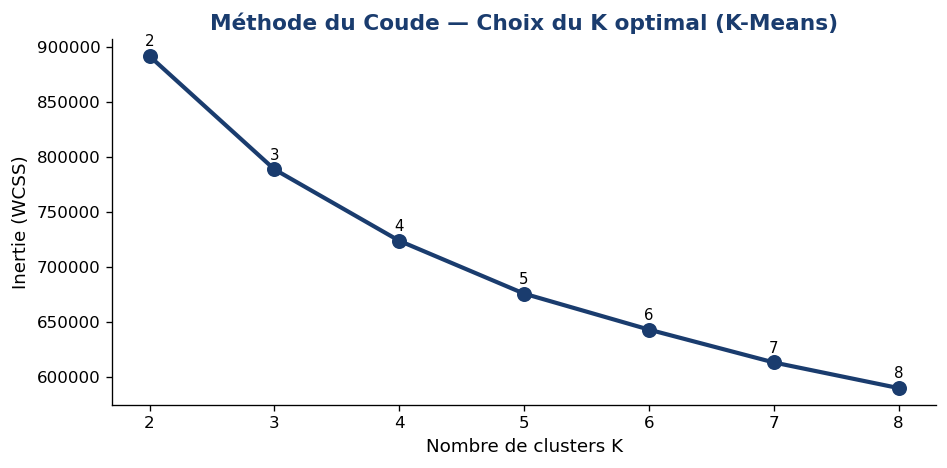

✅ fig_33_kmeans_elbow.png
→ Choisir K là où la courbe marque un coude (diminution brusque d'inertie ralentit)


In [17]:
# ── Choix du K optimal — Méthode du coude ────────────────────────────
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color=C1, lw=2.5, markersize=8)
for k, ine in zip(K_range, inertias):
    ax.text(k, ine + max(inertias)*0.01, str(k), ha='center', fontsize=9)
ax.set_xlabel('Nombre de clusters K')
ax.set_ylabel('Inertie (WCSS)')
ax.set_title('Méthode du Coude — Choix du K optimal (K-Means)', fontweight='bold', color=C1)
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.savefig('fig_33_kmeans_elbow.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ fig_33_kmeans_elbow.png')
print('→ Choisir K là où la courbe marque un coude (diminution brusque d\'inertie ralentit)')

In [18]:
# ── K-Means final (K=4 par défaut — ajuster selon coude) ─────────────
K_OPTIMAL = 4  # ← Ajuster selon la méthode du coude

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
df_model['cluster_kmeans'] = labels_km

print(f'K-Means K={K_OPTIMAL} :')
print(pd.Series(labels_km).value_counts().sort_index().to_string())

K-Means K=4 :
0    31677
1    37437
2    17438
3     8294


In [19]:
# ── DBSCAN ────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.8, min_samples=50, n_jobs=-1)
labels_db = dbscan.fit_predict(X_scaled)
df_model['cluster_dbscan'] = labels_db

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f'DBSCAN (eps=0.8, min_samples=50) :')
print(f'  Clusters détectés : {n_clusters_db}')
print(f'  Outliers (label=-1) : {n_noise:,} ({n_noise/len(labels_db)*100:.1f}%)')
print()
print(pd.Series(labels_db).value_counts().sort_index().to_string())

DBSCAN (eps=0.8, min_samples=50) :
  Clusters détectés : 8
  Outliers (label=-1) : 54,041 (57.0%)

-1    54041
 0    18700
 1    14394
 2     4696
 3     1311
 4      274
 5     1209
 6      170
 7       51


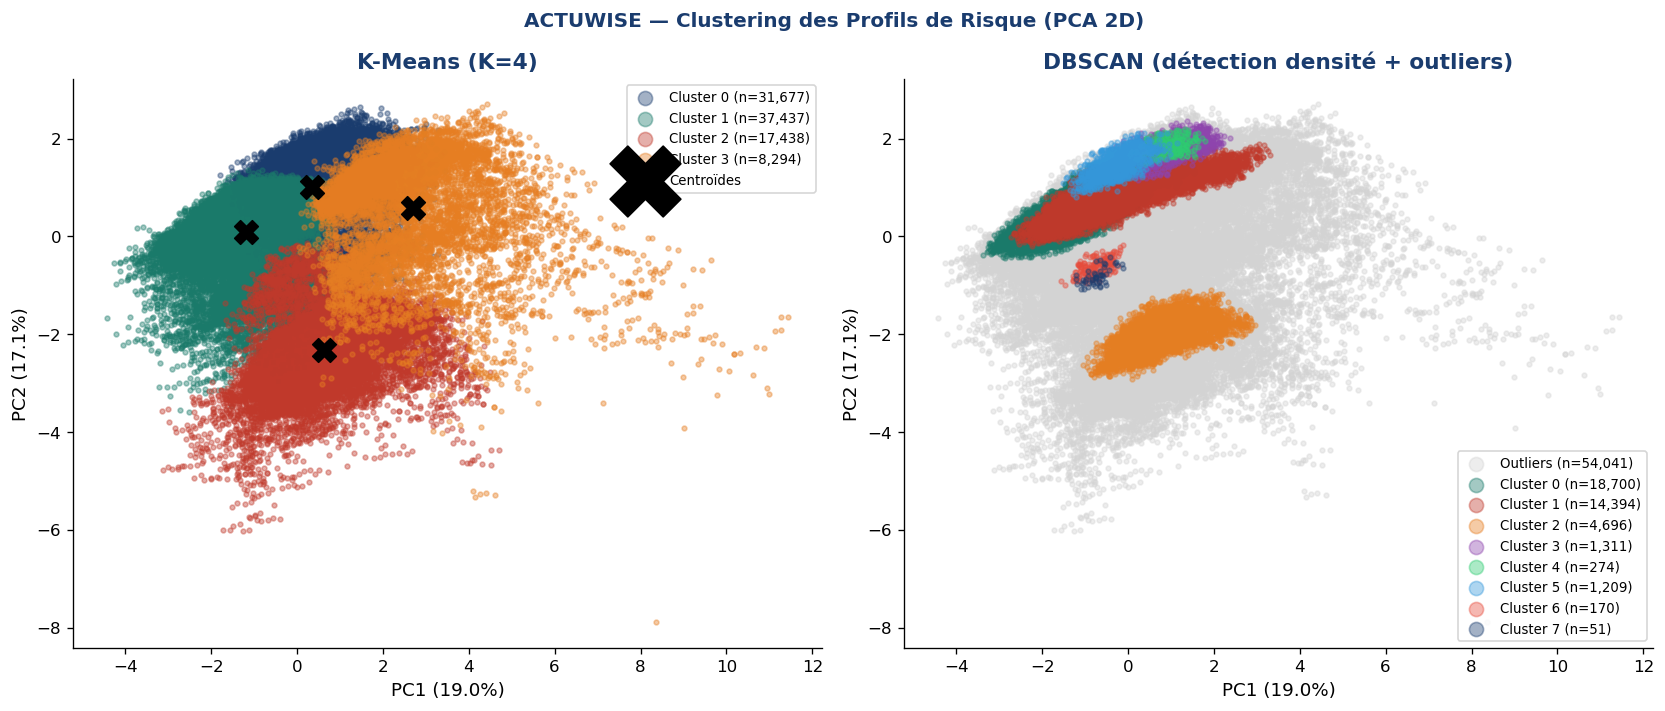

✅ fig_33_clustering_pca.png


In [20]:
# ── Visualisation PCA 2D ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ACTUWISE — Clustering des Profils de Risque (PCA 2D)', fontweight='bold', color=C1)

# K-Means
ax = axes[0]
for k in range(K_OPTIMAL):
    mask = labels_km == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=8, alpha=0.4, color=PALETTE[k], label=f'Cluster {k} (n={mask.sum():,})')
ax.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
           pca.transform(kmeans.cluster_centers_)[:, 1],
           s=200, color='black', marker='X', zorder=5, label='Centroïdes')
ax.set_title(f'K-Means (K={K_OPTIMAL})', fontweight='bold', color=C1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8, markerscale=3)

# DBSCAN
ax = axes[1]
unique_db = sorted(set(labels_db))
for i, lab in enumerate(unique_db):
    mask = labels_db == lab
    color = 'lightgrey' if lab == -1 else PALETTE[i % 8]
    label = f'Outliers (n={mask.sum():,})' if lab == -1 else f'Cluster {lab} (n={mask.sum():,})'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.4, color=color, label=label)
ax.set_title('DBSCAN (détection densité + outliers)', fontweight='bold', color=C1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.savefig('fig_33_clustering_pca.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ fig_33_clustering_pca.png')

## 9. Ratio Combiné par Cluster K-Means

Cette analyse répond à la question centrale : **les clusters identifiés correspondent-ils  
à des groupes de rentabilité distincte ?**  
Un cluster avec ratio combiné > 100 % est structurellement non rentable — cible prioritaire  
pour des ajustements tarifaires.

In [21]:
if col_primes and col_lr:
    df_model['primes'] = df_freq[col_primes].values
    df_model['loss_ratio'] = df_freq[col_lr].values
    df_model['ratio_combine'] = df_model['loss_ratio'] + RATIO_FRAIS

    rc_cluster = df_model.groupby('cluster_kmeans').agg(
        n_polices=('cluster_kmeans', 'count'),
        ratio_combine_moyen=('ratio_combine', 'mean'),
        prime_pure_xgb_moy=('prime_pure_xgb', 'mean'),
        taux_sinistre_moyen=('target_freq', 'mean')
    ).reset_index()

    print('=== Ratio Combiné par Cluster K-Means ===')
    for _, row in rc_cluster.iterrows():
        rc = row['ratio_combine_moyen']
        flag = '🔴 PERTE' if rc > 1.0 else ('🟡 ALERTE' if rc > 0.95 else '🟢 RENTABLE')
        print(f'  Cluster {int(row["cluster_kmeans"])} | N={row["n_polices"]:>7,} | '
              f'RC={rc*100:5.1f}% | Freq={row["taux_sinistre_moyen"]*100:.1f}% | '
              f'PP_XGB={row["prime_pure_xgb_moy"]:6.0f} DT  {flag}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('ACTUWISE — Profils de Risque par Cluster K-Means', fontweight='bold', color=C1)

    ax = axes[0]
    colors = [C3 if rc > 1.0 else (C4 if rc > 0.95 else C2)
              for rc in rc_cluster['ratio_combine_moyen']]
    bars = ax.bar(rc_cluster['cluster_kmeans'].astype(str),
                  rc_cluster['ratio_combine_moyen'], color=colors, edgecolor='white')
    ax.axhline(1.0, color='black', lw=2, ls='--', label='Perte technique 100%')
    ax.axhline(0.95, color=C4, lw=1.5, ls=':', label='Alerte 95%')
    for bar, val in zip(bars, rc_cluster['ratio_combine_moyen']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_title('Ratio Combiné par Cluster')
    ax.set_xlabel('Cluster K-Means')
    ax.set_ylabel('Ratio Combiné')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y*100:.0f}%'))
    ax.legend(fontsize=9)

    ax = axes[1]
    ax.scatter(rc_cluster['taux_sinistre_moyen']*100,
               rc_cluster['prime_pure_xgb_moy'],
               c=colors, s=rc_cluster['n_polices']/100, alpha=0.8, edgecolors='black')
    for _, row in rc_cluster.iterrows():
        ax.annotate(f'C{int(row["cluster_kmeans"])}\n(RC={row["ratio_combine_moyen"]*100:.0f}%)',
                    (row['taux_sinistre_moyen']*100, row['prime_pure_xgb_moy']),
                    textcoords='offset points', xytext=(8,0), fontsize=9)
    ax.set_xlabel('Taux de sinistralité moyen (%)')
    ax.set_ylabel('Prime Pure XGBoost moyenne (DT)')
    ax.set_title('Taux sinistralité vs Prime Pure par Cluster\n(taille ∝ nb polices)')

    plt.tight_layout()
    plt.savefig('fig_33_ratio_combine_clusters.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ fig_33_ratio_combine_clusters.png')
else:
    print('⚠️ Colonnes primes/loss_ratio absentes — ratio combiné par cluster non calculé')

⚠️ Colonnes primes/loss_ratio absentes — ratio combiné par cluster non calculé


## 10. Tableau Benchmark Complet — GLM vs XGBoost


In [22]:
print('=' * 65)
print('  ACTUWISE — BENCHMARK GLM vs XGBoost')
print('=' * 65)

rows = []

# GLM depuis fichier benchmark
try:
    df_bench_glm = pd.read_csv('benchmark_module_32_glm.csv', index_col=0)
    for col in df_bench_glm.columns:
        val = df_bench_glm.loc['GLM Baseline', col] if 'GLM Baseline' in df_bench_glm.index else None
        rows.append({'Modèle': 'GLM Baseline', 'Métrique': col, 'Valeur': val})
except: pass

# XGBoost
rows.append({'Modèle': 'XGBoost', 'Métrique': 'AUC-ROC (fréquence)', 'Valeur': round(auc_xgb_f, 4)})
rows.append({'Modèle': 'XGBoost', 'Métrique': 'Gini actuariel',      'Valeur': round(gini_xgb, 4)})
if rmse_xgb_s:  rows.append({'Modèle': 'XGBoost', 'Métrique': 'RMSE sévérité (DT)', 'Valeur': round(rmse_xgb_s, 2)})
if r2_xgb_s:    rows.append({'Modèle': 'XGBoost', 'Métrique': 'R² sévérité',        'Valeur': round(r2_xgb_s, 4)})
if mae_xgb_s:   rows.append({'Modèle': 'XGBoost', 'Métrique': 'MAE sévérité (DT)',  'Valeur': round(mae_xgb_s, 2)})

df_bench = pd.DataFrame(rows)
if len(df_bench):
    pivot = df_bench.pivot_table(values='Valeur', index='Métrique', columns='Modèle', aggfunc='first')
    print(pivot.to_string())
    pivot.to_csv('benchmark_module_33_xgb.csv')
    print('\n✅ Exporté → benchmark_module_33_xgb.csv')
else:
    print('⚠️ Données benchmark insuffisantes')

  ACTUWISE — BENCHMARK GLM vs XGBoost
Modèle                         GLM Baseline    XGBoost
Métrique                                              
AIC (fréquence)                 356915.3100        NaN
AIC (sévérité)                  667558.3200        NaN
AUC-ROC (fréquence)                     NaN     0.8460
Gini actuariel                      -0.0659    -0.3294
MAE sévérité (DT)                       NaN   846.9500
RMSE sévérité (DT)                3327.8400  3504.9300
Ratio déviance/df (fréquence)        2.5190        NaN
R² sévérité                          0.0038     0.0545

✅ Exporté → benchmark_module_33_xgb.csv


In [23]:
# ── Export prime pure XGBoost ─────────────────────────────────────────
df_export_xgb = pd.DataFrame({'prime_pure_xgb': prime_pure_xgb})
df_export_xgb.to_csv('prime_pure_xgb.csv', index=True)
print(f'✅ prime_pure_xgb.csv exporté ({len(df_export_xgb):,} lignes)')

# ── Export clusters ────────────────────────────────────────────────────
df_clusters = df_model[['cluster_kmeans', 'cluster_dbscan']].copy()
df_clusters.to_csv('clusters_module_33.csv', index=True)
print(f'✅ clusters_module_33.csv exporté')

✅ prime_pure_xgb.csv exporté (94,846 lignes)
✅ clusters_module_33.csv exporté


## 11. Insights Métier — XGBoost + Clustering


In [24]:
print('=' * 65)
print('  ACTUWISE — Module 3.3 : INSIGHTS MÉTIER')
print('=' * 65)

print('\n🤖 PERFORMANCE XGBoost vs GLM')
print(f'   AUC-ROC XGBoost fréquence   : {auc_xgb_f:.4f}')
print(f'   Gini XGBoost               : {gini_xgb:.4f}')
if gini_glm:
    delta = gini_xgb - gini_glm
    print(f'   Gini GLM                   : {gini_glm:.4f}')
    print(f'   Gain Gini XGBoost vs GLM   : +{delta:.4f} ({delta/abs(gini_glm)*100:.1f}%)')
    if delta > 0.05:
        print('   ✅ XGBoost apporte un gain significatif → recommandé pour la tarification')
    elif delta > 0.01:
        print('   🟡 Gain XGBoost marginal → évaluer le coût de complexité')
    else:
        print('   🟢 GLM suffisant — XGBoost n\'apporte pas de gain notable')

print('\n🎯 TOP FEATURES XGBoost Fréquence')
top_feats = pd.Series(xgb_freq.feature_importances_, index=feats_available).nlargest(5)
for feat, imp in top_feats.items():
    print(f'   {feat:<30}: importance = {imp:.4f}')

print('\n📊 CLUSTERING K-MEANS')
print(f'   K optimal retenu           : {K_OPTIMAL}')
if col_primes and col_lr:
    for _, row in rc_cluster.iterrows():
        rc = row['ratio_combine_moyen']
        profil = 'RISQUÉ' if rc > 1.0 else ('MOYEN' if rc > 0.95 else 'BON RISQUE')
        print(f'   Cluster {int(row["cluster_kmeans"])} → {profil} | RC={rc*100:.1f}% | N={row["n_polices"]:,}')

print('\n🔍 DBSCAN')
print(f'   Outliers détectés          : {n_noise:,} ({n_noise/len(labels_db)*100:.1f}%)')
print('   → Ces assurés ont un profil atypique : vérification manuelle recommandée')

print('\n' + '=' * 65)
print('→ Livrables pour Notebook 3.4 (SHAP) :')
print('  • xgb_freq, xgb_sev     — modèles entraînés (à passer en mémoire)')
print('  • feats_available        — liste des features XGBoost')
print('  • prime_pure_xgb.csv     — primes pour benchmark final')
print('  • benchmark_module_33_xgb.csv')
print('=' * 65)

  ACTUWISE — Module 3.3 : INSIGHTS MÉTIER

🤖 PERFORMANCE XGBoost vs GLM
   AUC-ROC XGBoost fréquence   : 0.8460
   Gini XGBoost               : -0.3294
   Gini GLM                   : -0.0659
   Gain Gini XGBoost vs GLM   : +-0.2635 (-399.9%)
   🟢 GLM suffisant — XGBoost n'apporte pas de gain notable

🎯 TOP FEATURES XGBoost Fréquence
   Usage_Promenade et affaire    : importance = 0.1347
   Classe BM                     : importance = 0.1280
   anciennete_vehicule           : importance = 0.1106
   Valeur venale                 : importance = 0.1043
   sexe_masculin                 : importance = 0.0988

📊 CLUSTERING K-MEANS
   K optimal retenu           : 4

🔍 DBSCAN
   Outliers détectés          : 54,041 (57.0%)
   → Ces assurés ont un profil atypique : vérification manuelle recommandée

→ Livrables pour Notebook 3.4 (SHAP) :
  • xgb_freq, xgb_sev     — modèles entraînés (à passer en mémoire)
  • feats_available        — liste des features XGBoost
  • prime_pure_xgb.csv     — primes 

## 12. Livrables pour le Notebook 3.4

| Fichier | Contenu | Utilisé dans |
|---------|---------|------|
| `prime_pure_xgb.csv` | Prime pure XGBoost par assuré | Notebook 3.6 |
| `benchmark_module_33_xgb.csv` | Métriques comparées GLM vs XGBoost | Notebook 3.6 |
| `clusters_module_33.csv` | Labels K-Means + DBSCAN par assuré | Notebook 3.6 |
| `fig_33_lorenz_benchmark.png` | Lorenz GLM vs XGBoost | Notebook 3.6 |

**Ce que le Notebook 3.4 va faire :**
- Appliquer SHAP sur `xgb_freq` et `xgb_sev` (modèles entraînés dans ce notebook)
- Produire les summary plots globaux, les dependence plots pour les 5 top features
- Générer les waterfall plots individuels pour 3 profils types issus du clustering K-Means

---
*ACTUWISE — Notebook 3.3 terminé ✅*

In [25]:
# ── Sauvegarde des modèles XGBoost + Clustering ───────────────────────
import joblib, os

os.makedirs('models', exist_ok=True)

joblib.dump(xgb_freq,  'models/xgb_freq.pkl')
joblib.dump(xgb_sev,   'models/xgb_sev.pkl')
joblib.dump(kmeans,    'models/kmeans.pkl')
joblib.dump(scaler,    'models/scaler_cluster.pkl')
joblib.dump(le_dict,   'models/label_encoders.pkl')

print('✅ models/xgb_freq.pkl')
print('✅ models/xgb_sev.pkl')
print('✅ models/kmeans.pkl')
print('✅ models/scaler_cluster.pkl')
print('✅ models/label_encoders.pkl')

# Téléchargement
try:
    from IPython.display import FileLink, display
    for f in ['xgb_freq', 'xgb_sev', 'kmeans', 'scaler_cluster', 'label_encoders']:
        display(FileLink(f'models/{f}.pkl'))
except:
    print('→ Télécharge depuis le dossier models/')

✅ models/xgb_freq.pkl
✅ models/xgb_sev.pkl
✅ models/kmeans.pkl
✅ models/scaler_cluster.pkl
✅ models/label_encoders.pkl


c:\Users\LENOVO\Desktop\Actuariat\Module3\models\xgb_freq.pkl

c:\Users\LENOVO\Desktop\Actuariat\Module3\models\xgb_sev.pkl

c:\Users\LENOVO\Desktop\Actuariat\Module3\models\kmeans.pkl

c:\Users\LENOVO\Desktop\Actuariat\Module3\models\scaler_cluster.pkl

c:\Users\LENOVO\Desktop\Actuariat\Module3\models\label_encoders.pkl